# Omission Error Rate

> Identify which study positions are most likely to be forgotten.

An omission error occurs when a participant fails to recall an item that was presented on the study list. The omission error rate curve plots the proportion of omissions at each study position, revealing which serial positions are most vulnerable to being forgotten entirely.

## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.omission_error_rate import plot_omission_error_rate
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/RepeatedRecallsKahanaJacobs2000.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listLength'] > 0"
size = 3
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

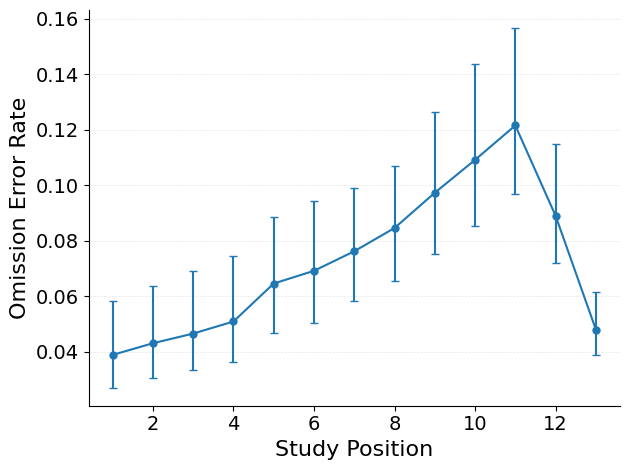

In [4]:
plot_omission_error_rate(datasets=data, trial_masks=trial_mask, size=size, confidence_level=confidence_level)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The x-axis shows study position and the y-axis shows the proportion of trials on which that item was not recalled. Key patterns:

- **U-shaped inverse of SPC**: middle positions have the highest omission rates, mirroring the serial position curve.
- **Low at extremes**: primacy and recency positions are rarely omitted.

## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `size` — maximum number of study positions a single item can occupy.
- `confidence_level` — confidence level for subject-wise error bars.
